# Timescale analysis: single-AP Ca2+ / release cascade (v2)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from scipy.optimize import curve_fit, minimize_scalar, minimize

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
LABEL_FS, TICK_FS, LEG_FS, LW = 12, 10, 9, 2.0

# ---------------- Raw data locations ----------------
dir_control = 'RSV80C250uM_nish2sur_nishRyR_single_pulse'
base_path   = "/data/hdrive/phd/results/single_pulse/"
ap_path     = "/data/hdrive/Downloads/VDCC potential/AP.dat"
DATA_DIR    = f"{base_path}/{dir_control}"

SAVE_FIGS = True
DPI = 200

def load(fname, usecols=None):
    return np.genfromtxt(f"{DATA_DIR}/{fname}", usecols=usecols)

results = []  # one dict per extracted timescale -> summary table at the end


## Helper functions

Three families of fit, used depending on what the rising/falling phase
physically represents:

- **Model-free (1/e-crossing) metrics** -- always computed, always robust,
  used as the primary number whenever a parametric fit isn't appropriate.
- **Relaxation fits** (`fit_exp_decay`, `fit_biexp_decay`, `fit_exp_rise`) --
  for processes relaxing toward a new steady state (buffer binding, store
  depletion, channel-flux decay). Support optional relative-error
  weighting (`weighted=True`) for signals spanning multiple orders of
  magnitude, where unweighted least squares is dominated by the largest
  values.
- **Driven-response fit** (`fit_sigmoid_rise`) -- for channel-gating-type
  rises that are actively driven by a fast, non-step stimulus (the AP
  waveform / a rapidly rising flux) and are therefore S-shaped
  (accelerating then decelerating), not a simple decelerating exponential
  approach to plateau.


In [2]:
def smooth(x, win):
    """Centered moving-average smoothing (win = # samples, forced odd)."""
    if win <= 1:
        return x
    if win % 2 == 0:
        win += 1
    kernel = np.ones(win) / win
    pad = win // 2
    xp = np.pad(x, pad, mode='edge')
    return np.convolve(xp, kernel, mode='valid')


def time_to_peak(t, y, idx_start):
    seg = y[idx_start:]
    idx = np.argmax(seg) + idx_start
    return t[idx], y[idx], idx


def rise_time_10_90(t, y, idx_start, idx_peak, baseline):
    """Time between 10% and 90% of (peak-baseline) on the rising edge."""
    peak = y[idx_peak]
    lo = baseline + 0.10 * (peak - baseline)
    hi = baseline + 0.90 * (peak - baseline)
    seg_t = t[idx_start:idx_peak + 1]
    seg_y = y[idx_start:idx_peak + 1]
    if len(seg_y) < 2:
        return np.nan
    order = np.argsort(seg_y)
    t_lo = np.interp(lo, seg_y[order], seg_t[order])
    t_hi = np.interp(hi, seg_y[order], seg_t[order])
    return t_hi - t_lo


def decay_time_to_fraction(t, y, idx_peak, baseline, frac=1/np.e, idx_end=None):
    """Model-free decay time constant: time from peak to the first crossing
    of baseline + frac*(peak-baseline). frac=1/e mimics a single-exponential tau."""
    peak = y[idx_peak]
    target = baseline + frac * (peak - baseline)
    idx_end = len(y) if idx_end is None else idx_end
    seg = y[idx_peak:idx_end]
    cross = np.where(seg <= target)[0] if peak > baseline else np.where(seg >= target)[0]
    if len(cross) == 0:
        return np.nan
    idx_c = idx_peak + cross[0]
    if idx_c == idx_peak:
        return 0.0
    y0, y1, t0, t1 = y[idx_c - 1], y[idx_c], t[idx_c - 1], t[idx_c]
    frac_step = 0.0 if y1 == y0 else (target - y0) / (y1 - y0)
    return (t0 + frac_step * (t1 - t0)) - t[idx_peak]


def rise_time_to_fraction(t, y, idx_start, y_final, baseline, frac=1 - 1/np.e, idx_end=None):
    """Model-free rise time constant for a saturating/relaxing signal."""
    target = baseline + frac * (y_final - baseline)
    idx_end = len(y) if idx_end is None else idx_end
    seg = y[idx_start:idx_end]
    cross = np.where(seg >= target)[0] if y_final > baseline else np.where(seg <= target)[0]
    if len(cross) == 0:
        return np.nan
    idx_c = idx_start + cross[0]
    if idx_c == idx_start:
        return 0.0
    y0, y1, t0, t1 = y[idx_c - 1], y[idx_c], t[idx_c - 1], t[idx_c]
    frac_step = 0.0 if y1 == y0 else (target - y0) / (y1 - y0)
    return (t0 + frac_step * (t1 - t0)) - t[idx_start]


def detect_onset(t, y, idx_search_start, idx_search_end, frac=0.05, rising=True):
    """Find the first index where y departs from its pre-onset baseline by
    `frac` of its eventual total excursion. Used to separate a genuine
    reaction/relaxation onset from a flat lag phase, so that a subsequent
    exponential fit isn't forced to explain a delay it cannot represent."""
    baseline = np.median(y[max(0, idx_search_start - 50):idx_search_start]) if idx_search_start > 0 else y[0]
    y_ref = y[idx_search_end]
    thresh = baseline + frac * (y_ref - baseline)
    seg = y[idx_search_start:idx_search_end]
    cross = np.where(seg >= thresh)[0] if y_ref > baseline else np.where(seg <= thresh)[0]
    return idx_search_start + cross[0] if len(cross) else idx_search_start


# ---------------- relaxation fits (optionally relative-error weighted) ----------------

def _exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C


def _exp_rise(t, A, tau, C):
    return A * (1 - np.exp(-t / tau)) + C


def _biexp_decay(t, A1, tau1, A2, tau2, C):
    return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2) + C


def _sigma_for(yy, weighted):
    return np.clip(np.abs(yy), 1.0, None) if weighted else None


def fit_exp_decay(t, y, idx_peak, idx_end, p0_tau, fix_zero_baseline=False, weighted=False):
    tt, yy = t[idx_peak:idx_end] - t[idx_peak], y[idx_peak:idx_end]
    if len(tt) < 5:
        return None
    sigma = _sigma_for(yy, weighted)
    try:
        if fix_zero_baseline:
            def f(t, A, tau):
                return A * np.exp(-t / tau)
            popt, pcov = curve_fit(f, tt, yy, p0=[yy[0], p0_tau], sigma=sigma, maxfev=20000,
                                    bounds=([-np.inf, 1e-7], [np.inf, np.inf]))
            perr = np.sqrt(np.diag(pcov))
            return dict(A=popt[0], tau=popt[1], C=0.0, tau_err=perr[1],
                        fit_t=tt, fit_y=f(tt, *popt))
        popt, pcov = curve_fit(_exp_decay, tt, yy, p0=[yy[0] - yy[-1], p0_tau, yy[-1]], sigma=sigma,
                                maxfev=20000, bounds=([-np.inf, 1e-7, -np.inf], [np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        return dict(A=popt[0], tau=popt[1], C=popt[2], tau_err=perr[1],
                    fit_t=tt, fit_y=_exp_decay(tt, *popt))
    except Exception:
        return None


def fit_exp_rise(t, y, idx_start, idx_end, p0_tau, weighted=False):
    tt, yy = t[idx_start:idx_end] - t[idx_start], y[idx_start:idx_end]
    if len(tt) < 5:
        return None
    sigma = _sigma_for(yy - yy[0], weighted)
    try:
        popt, pcov = curve_fit(_exp_rise, tt, yy, p0=[yy[-1] - yy[0], p0_tau, yy[0]], sigma=sigma,
                                maxfev=20000, bounds=([-np.inf, 1e-7, -np.inf], [np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        return dict(A=popt[0], tau=popt[1], C=popt[2], tau_err=perr[1],
                    fit_t=tt, fit_y=_exp_rise(tt, *popt))
    except Exception:
        return None


def fit_biexp_decay(t, y, idx_peak, idx_end, p0_tau1, p0_tau2, weighted=False):
    """Fast+slow decay: A1*exp(-t/tau1) + A2*exp(-t/tau2) + C. Returns tau1<tau2."""
    tt, yy = t[idx_peak:idx_end] - t[idx_peak], y[idx_peak:idx_end]
    if len(tt) < 10:
        return None
    C0 = yy[-1]
    A0 = yy[0] - C0
    p0 = [A0 * 0.7, p0_tau1, A0 * 0.3, p0_tau2, C0]
    sigma = _sigma_for(yy, weighted)
    try:
        popt, pcov = curve_fit(_biexp_decay, tt, yy, p0=p0, sigma=sigma, maxfev=40000,
                                bounds=([-np.inf, 1e-7, -np.inf, 1e-7, -np.inf],
                                        [np.inf, np.inf, np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        A1, tau1, A2, tau2, C = popt
        e1, e2 = perr[1], perr[3]
        if tau1 > tau2:
            A1, tau1, A2, tau2 = A2, tau2, A1, tau1
            e1, e2 = e2, e1
        return dict(A1=A1, tau1=tau1, tau1_err=e1, A2=A2, tau2=tau2, tau2_err=e2, C=C,
                    fit_t=tt, fit_y=_biexp_decay(tt, *popt))
    except Exception:
        return None


def fit_biexp_deplete(t, y, idx_onset, idx_end, p0_tau1, p0_tau2, weighted=False):
    """Two-timescale depletion (y falls from a baseline): C - A1*(1-e^-t/tau1) - A2*(1-e^-t/tau2)."""
    tt, yy = t[idx_onset:idx_end] - t[idx_onset], y[idx_onset:idx_end]
    if len(tt) < 10:
        return None
    C0 = yy[0]
    total_drop = C0 - yy[-1]
    p0 = [total_drop * 0.5, p0_tau1, total_drop * 0.5, p0_tau2, C0]

    def f(t, A1, tau1, A2, tau2, C):
        return C - A1 * (1 - np.exp(-t / tau1)) - A2 * (1 - np.exp(-t / tau2))

    sigma = _sigma_for(yy, weighted)
    try:
        popt, pcov = curve_fit(f, tt, yy, p0=p0, sigma=sigma, maxfev=80000,
                                bounds=([-np.inf, 1e-7, -np.inf, 1e-7, -np.inf],
                                        [np.inf, np.inf, np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        A1, tau1, A2, tau2, C = popt
        e1, e2 = perr[1], perr[3]
        if tau1 > tau2:
            A1, tau1, A2, tau2 = A2, tau2, A1, tau1
            e1, e2 = e2, e1
        resid = yy - f(tt, *popt)
        r2 = 1 - np.sum(resid ** 2) / np.sum((yy - yy.mean()) ** 2)
        return dict(A1=A1, tau1=tau1, tau1_err=e1, A2=A2, tau2=tau2, tau2_err=e2, C=C, r2=r2,
                    fit_t=tt, fit_y=f(tt, *popt))
    except Exception:
        return None


def fit_exp_deplete_single(t, y, idx_onset, idx_end, p0_tau, weighted=False):
    tt, yy = t[idx_onset:idx_end] - t[idx_onset], y[idx_onset:idx_end]
    C0 = yy[0]

    def f(t, A, tau, C):
        return C - A * (1 - np.exp(-t / tau))

    sigma = _sigma_for(yy, weighted)
    try:
        popt, pcov = curve_fit(f, tt, yy, p0=[C0 - yy[-1], p0_tau, C0], sigma=sigma, maxfev=40000,
                                bounds=([-np.inf, 1e-7, -np.inf], [np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        resid = yy - f(tt, *popt)
        r2 = 1 - np.sum(resid ** 2) / np.sum((yy - yy.mean()) ** 2)
        return dict(A=popt[0], tau=popt[1], C=popt[2], tau_err=perr[1], r2=r2,
                    fit_t=tt, fit_y=f(tt, *popt))
    except Exception:
        return None


# ---------------- driven-response (sigmoid) fit for channel-gating rises ----------------

def _sigmoid(t, A, tau, thalf, C):
    return C + A / (1 + np.exp(-(t - thalf) / tau))


def fit_sigmoid_rise(t, y, idx_start, idx_end, p0_tau=None):
    """Logistic-sigmoid fit to a driven rise, with sqrt (Poisson-motivated)
    weighting and A/C bounded >= 0 (flux/concentration can't go negative)."""
    tt, yy = t[idx_start:idx_end] - t[idx_start], y[idx_start:idx_end]
    if len(tt) < 5:
        return None
    p0_tau = p0_tau or (tt[-1] - tt[0]) / 6
    p0 = [max(yy[-1] - yy[0], 1e-9), p0_tau, tt[len(tt) // 2], max(yy[0], 0.0)]
    sigma = np.sqrt(np.clip(yy, 1e-6, None))
    try:
        popt, pcov = curve_fit(_sigmoid, tt, yy, p0=p0, sigma=sigma, maxfev=50000,
                                bounds=([0, 1e-7, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf]))
        perr = np.sqrt(np.diag(pcov))
        resid = yy - _sigmoid(tt, *popt)
        r2 = 1 - np.sum(resid ** 2) / np.sum((yy - yy.mean()) ** 2)
        return dict(A=popt[0], tau=popt[1], t_half=popt[2], C=popt[3], tau_err=perr[1], r2=r2,
                    fit_t=tt, fit_y=_sigmoid(tt, *popt))
    except Exception:
        return None


# ---------------- point-process (release event) fits ----------------

def negloglik_trunc_exp(tau, data, T):
    n = len(data)
    if tau <= 1e-8:
        return 1e18
    return -(-np.sum(data) / tau - n * np.log(tau) - n * np.log(1 - np.exp(-T / tau)))


def fit_truncated_exp_mle(data, T):
    """MLE tau for iid Exponential(tau) truncated to the observation window [0,T] --
    the statistically correct model for a set of individual event times."""
    res = minimize_scalar(negloglik_trunc_exp, bounds=(1e-5, 1.0), args=(data, T),
                           method='bounded', options={'xatol': 1e-9})
    return res.x, -res.fun


def loglik_uniform(data, T):
    """Log-likelihood of the same data under a constant-rate (uniform-in-time) null
    model with zero free parameters -- each event time ~ Uniform(0, T)."""
    return -len(data) * np.log(T)


# ---------------- adaptive-window fits (v3: fixes peak/onset "rounding" mismatch) ----------------

def find_true_onset(t, y, idx_ref, idx_peak, search_before_s=0.0015, eps=0.5):
    """First index where y departs from an exactly-zero baseline, searching
    from `search_before_s` seconds before idx_ref up to idx_peak. Use this
    (not idx_ref = the AP-upstroke time) as the rise-fit start for channel
    fluxes: VDCC/RyR current can begin rising measurably before the AP's
    steepest point, and fitting from idx_ref alone truncates that early
    part of the rise, so the fit visually starts "mid-climb"."""
    idx_search_start = np.searchsorted(t, t[idx_ref] - search_before_s)
    nz = np.where(y[idx_search_start:idx_peak + 1] > eps)[0]
    return idx_search_start + nz[0] if len(nz) else idx_ref


def adaptive_shift_fit(t, y, idx_ref, idx_end, order, p0_taus, r2_tol=0.995, max_shift=25, min_pts=6):
    """Fit a mono- or bi-exponential decay/rise, searching for the smallest
    start-shift past idx_ref at which R^2 >= r2_tol. A true local extremum
    (a peak, or a rise's own onset) has zero slope there by definition,
    but a sum of decaying/saturating exponentials is *maximally* steep at
    its own t=0 -- no such sum can ever match a rounded extremum exactly,
    so forcing the fit to start exactly at idx_ref biases the whole curve. Skipping forward in
    small steps until the model actually matches the local data removes
    that bias while changing tau only modestly. Uses sqrt (Poisson-
    motivated) weighting throughout. Returns the best (highest-R^2) fit
    found even if r2_tol is never reached within max_shift.
    """
    is_decay = order.endswith('decay')
    biexp = order.startswith('biexp')
    base_model = {'mono_decay': _exp_decay_free, 'biexp_decay': _biexp_decay,
                  'mono_rise': _exp_rise_free, 'biexp_rise': _biexp_rise_free}[order]

    best = None
    for shift in range(0, max_shift + 1):
        s = idx_ref + shift
        if s >= idx_end - min_pts:
            break
        tt = t[s:idx_end] - t[s]
        yy = y[s:idx_end]
        anchor = yy[-1] if is_decay else yy[0]
        C0 = yy[-1] if is_decay else yy[0]
        A0 = (yy[0] - yy[-1]) if is_decay else (yy[-1] - yy[0])
        sigma = np.sqrt(np.clip(np.abs(yy - anchor), 1, None))
        try:
            if biexp:
                p0 = [A0 * 0.7, p0_taus[0], A0 * 0.3, p0_taus[1], C0]
                bounds = ([-np.inf, 1e-7, -np.inf, 1e-7, -np.inf], [np.inf] * 5)
            else:
                p0 = [A0, p0_taus[0], C0]
                bounds = ([-np.inf, 1e-7, -np.inf], [np.inf] * 3)
            popt, pcov = curve_fit(base_model, tt, yy, p0=p0, sigma=sigma, maxfev=40000, bounds=bounds)
        except Exception:
            continue
        resid = yy - base_model(tt, *popt)
        r2 = 1 - np.sum(resid**2) / np.sum((yy - yy.mean())**2)
        perr = np.sqrt(np.diag(pcov))
        if biexp:
            order_idx = np.argsort([popt[1], popt[3]])
            taus = [ [popt[1], popt[3]][i] for i in order_idx]
            tau_errs = [ [perr[1], perr[3]][i] for i in order_idx]
        else:
            taus, tau_errs = [popt[1]], [perr[1]]
        entry = dict(shift=shift, popt=popt, pcov=pcov, tt=tt, yy=yy, r2=r2,
                     taus=taus, tau_errs=tau_errs, t_start=t[s], model=base_model,
                     fit_y=base_model(tt, *popt))
        if best is None or r2 > best['r2']:
            best = entry
        if r2 >= r2_tol:
            return entry
    return best


def _exp_decay_free(t, A, tau, C):
    return A * np.exp(-t / tau) + C


def _exp_rise_free(t, A, tau, C):
    return C + A * (1 - np.exp(-t / tau))


def _biexp_rise_free(t, A1, tau1, A2, tau2, C):
    return C + A1 * (1 - np.exp(-t / tau1)) + A2 * (1 - np.exp(-t / tau2))


# ---------------- delayed point-process models (v3: fixes async CDF mismatch) ----------------

def negloglik_delayed_trunc_exp(params, data, T):
    d, log_tau = params
    tau = np.exp(log_tau)
    if d < 0 or d >= data.min():
        return 1e18
    shifted, Trem = data - d, T - d
    if Trem <= 0:
        return 1e18
    n = len(data)
    return -(-np.sum(shifted) / tau - n * np.log(tau) - n * np.log(1 - np.exp(-Trem / tau)))


def fit_delayed_trunc_exp_mle(data, T, tau_grid=(0.0003, 3.0), n_grid=40):
    """MLE for events ~ d + Exponential(tau), truncated to [d, T]. Grid-search
    initializes (d, log tau) before a Nelder-Mead refine, since the surface
    is flat enough for small n that a plain local optimizer can get stuck."""
    d_grid = np.linspace(0, data.min() * 0.999, n_grid)
    logtau_grid = np.linspace(np.log(tau_grid[0]), np.log(tau_grid[1]), n_grid)
    best = None
    for d in d_grid:
        for lt in logtau_grid:
            val = negloglik_delayed_trunc_exp([d, lt], data, T)
            if best is None or val < best[0]:
                best = (val, d, lt)
    res = minimize(negloglik_delayed_trunc_exp, x0=[best[1], best[2]], args=(data, T),
                    method='Nelder-Mead', options={'xatol': 1e-10, 'fatol': 1e-10, 'maxiter': 20000})
    d_opt, logtau_opt = res.x
    return d_opt, np.exp(logtau_opt), -res.fun


def fit_delayed_uniform_mle(data, T):
    """MLE for events ~ Uniform(d, T): the boundary MLE is simply d = min(data)."""
    d_hat = data.min()
    ll = -len(data) * np.log(T - d_hat)
    return d_hat, ll


## 1. Stimulus timing reference

All timescales below are measured relative to the moment of the AP
upstroke (max dV/dt), not the start of the recording window, so that
"time-to-peak" and "decay tau" reflect the biological response latency
rather than an arbitrary trace offset.

In [3]:
ap_t = np.genfromtxt(ap_path, usecols=0)
ap_v = np.genfromtxt(ap_path, usecols=1)

dv = np.gradient(ap_v, ap_t)
idx_stim = np.argmax(dv)
t_stim = ap_t[idx_stim]

print(f"AP upstroke (max dV/dt): t_stim = {t_stim*1000:.3f} ms  (V = {ap_v[idx_stim]:.1f} mV)")
print(f"AP peak: t = {ap_t[np.argmax(ap_v)]*1000:.3f} ms  (V_max = {ap_v.max():.1f} mV)")


AP upstroke (max dV/dt): t_stim = 10.640 ms  (V = 9.9 mV)
AP peak: t = 10.810 ms  (V_max = 39.2 mV)


## 2. Channel-level Ca2+ flux kinetics (VDCC vs. RyR)


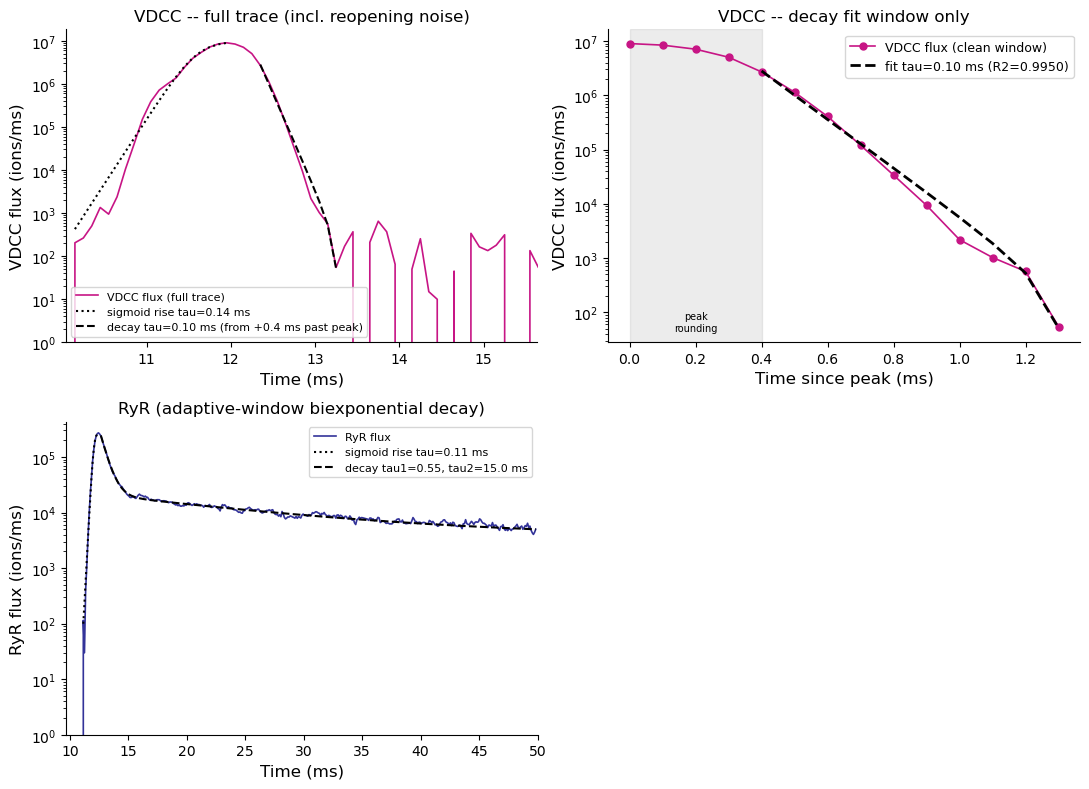

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# ---------------- VDCC ----------------
t = load("vdccCaFluxRate.dat", 0); f = load("vdccCaFluxRate.dat", 1)
idx0 = np.searchsorted(t, t_stim)
t_pk, y_pk, idx_pk = time_to_peak(t, f, idx0)
baseline = 0.0

idx_onset_vdcc = find_true_onset(t, f, idx0, idx_pk)

ttp = (t_pk - t_stim) * 1000
rt1090 = rise_time_10_90(t, f, idx_onset_vdcc, idx_pk, baseline) * 1000
sig_vdcc = fit_sigmoid_rise(t, f, idx_onset_vdcc, idx_pk + 1)

# clean decay window: stop at the first upward (non-monotonic / noise) step after the peak
seg_diff = np.diff(f[idx_pk:idx_pk + 200])
up = np.where(seg_diff > 0)[0]
idx_clean_end = idx_pk + (up[0] + 1 if len(up) else 20)

dec_1e = decay_time_to_fraction(t, f, idx_pk, baseline, idx_end=idx_clean_end) * 1000

fit_vdcc = adaptive_shift_fit(t, f, idx_pk, idx_clean_end, 'mono_decay', p0_taus=[1e-4],
                               r2_tol=0.995, min_pts=5)

ax = axes[0, 0]
ax.plot(t*1000, f, color='mediumvioletred', lw=1.2, label='VDCC flux (full trace)')
if sig_vdcc:
    ax.plot((sig_vdcc['fit_t']+t[idx_onset_vdcc])*1000, sig_vdcc['fit_y'], color='black', lw=1.5, ls=':',
            label=f"sigmoid rise tau={sig_vdcc['tau']*1000:.2f} ms")
if fit_vdcc:
    ax.plot((fit_vdcc['tt']+fit_vdcc['t_start'])*1000, fit_vdcc['fit_y'], 'k--', lw=1.5,
            label=f"decay tau={fit_vdcc['taus'][0]*1000:.2f} ms (from +{fit_vdcc['shift']*0.1:.1f} ms past peak)")
ax.set_yscale('log'); ax.set_ylim(bottom=1)
ax.set_xlim((t_stim-0.0006)*1000, (t_stim+0.005)*1000)
ax.set_xlabel('Time (ms)', fontsize=LABEL_FS); ax.set_ylabel('VDCC flux (ions/ms)', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS-1); ax.set_title('VDCC -- full trace (incl. reopening noise)', fontsize=LABEL_FS)

ax = axes[0, 1]
ax.set_yscale('log')
clean_t = (t[idx_pk:idx_clean_end] - t[idx_pk]) * 1000
ax.plot(clean_t, f[idx_pk:idx_clean_end], 'o-', color='mediumvioletred', ms=5, lw=1.2, label='VDCC flux (clean window)')
if fit_vdcc:
    ax.plot((fit_vdcc['tt']+fit_vdcc['t_start']-t[idx_pk])*1000, fit_vdcc['fit_y'], 'k--', lw=2,
            label=f"fit tau={fit_vdcc['taus'][0]*1000:.2f} ms (R2={fit_vdcc['r2']:.4f})")
    ax.axvspan(0, fit_vdcc['shift']*0.1, color='grey', alpha=0.15)
    ax.text(fit_vdcc['shift']*0.05, 0.03, 'peak\nrounding', fontsize=7, ha='center', va='bottom',
            transform=ax.get_xaxis_transform())
ax.set_xlabel('Time since peak (ms)', fontsize=LABEL_FS); ax.set_ylabel('VDCC flux (ions/ms)', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS); ax.set_title('VDCC -- decay fit window only', fontsize=LABEL_FS)

results.append(dict(category='Channel flux', signal='VDCC', metric='time to peak', value_ms=ttp))
results.append(dict(category='Channel flux', signal='VDCC', metric='rise time (10-90%, model-free)', value_ms=rt1090))
if sig_vdcc:
    results.append(dict(category='Channel flux', signal='VDCC', metric='rise tau (sigmoid fit, true onset)',
                         value_ms=sig_vdcc['tau']*1000, err_ms=sig_vdcc['tau_err']*1000))
results.append(dict(category='Channel flux', signal='VDCC', metric='decay tau (1/e, model-free, clean window)', value_ms=dec_1e))
if fit_vdcc:
    results.append(dict(category='Channel flux', signal='VDCC', metric='decay tau (exp fit, adaptive window)',
                         value_ms=fit_vdcc['taus'][0]*1000, err_ms=fit_vdcc['tau_errs'][0]*1000))

# ---------------- RyR ----------------
t = load("ryrCaFluxRate.dat", 0); f = load("ryrCaFluxRate.dat", 1)
idx0 = np.searchsorted(t, t_stim)
t_pk, y_pk, idx_pk = time_to_peak(t, f, idx0)
baseline = 0.0

idx_onset_ryr = find_true_onset(t, f, idx0, idx_pk)

ttp = (t_pk - t_stim) * 1000
rt1090 = rise_time_10_90(t, f, idx_onset_ryr, idx_pk, baseline) * 1000
sig_ryr = fit_sigmoid_rise(t, f, idx_onset_ryr, idx_pk + 1)
dec_1e = decay_time_to_fraction(t, f, idx_pk, baseline) * 1000
fit_ryr = adaptive_shift_fit(t, f, idx_pk, len(t), 'biexp_decay', p0_taus=[5e-4, 0.015], r2_tol=0.998)

ax = axes[1, 0]
ax.plot(t*1000, f, color='navy', lw=1.2, alpha=0.8, label='RyR flux')
if sig_ryr:
    ax.plot((sig_ryr['fit_t']+t[idx_onset_ryr])*1000, sig_ryr['fit_y'], color='black', lw=1.5, ls=':',
            label=f"sigmoid rise tau={sig_ryr['tau']*1000:.2f} ms")
if fit_ryr:
    ax.plot((fit_ryr['tt']+fit_ryr['t_start'])*1000, fit_ryr['fit_y'], 'k--', lw=1.5,
            label=f"decay tau1={fit_ryr['taus'][0]*1000:.2f}, tau2={fit_ryr['taus'][1]*1000:.1f} ms")
ax.set_yscale('log'); ax.set_ylim(bottom=1)
ax.set_xlim((t_stim-0.001)*1000, 50)
ax.set_xlabel('Time (ms)', fontsize=LABEL_FS); ax.set_ylabel('RyR flux (ions/ms)', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS-1); ax.set_title('RyR (adaptive-window biexponential decay)', fontsize=LABEL_FS)

axes[1, 1].axis('off')

results.append(dict(category='Channel flux', signal='RyR', metric='time to peak', value_ms=ttp))
results.append(dict(category='Channel flux', signal='RyR', metric='rise time (10-90%, model-free)', value_ms=rt1090))
if sig_ryr:
    results.append(dict(category='Channel flux', signal='RyR', metric='rise tau (sigmoid fit, true onset)',
                         value_ms=sig_ryr['tau']*1000, err_ms=sig_ryr['tau_err']*1000))
results.append(dict(category='Channel flux', signal='RyR', metric='decay tau (1/e, model-free)', value_ms=dec_1e))
if fit_ryr:
    results.append(dict(category='Channel flux', signal='RyR', metric='decay tau (fast, exp fit, adaptive window)',
                         value_ms=fit_ryr['taus'][0]*1000, err_ms=fit_ryr['tau_errs'][0]*1000))
    results.append(dict(category='Channel flux', signal='RyR', metric='decay tau (slow, exp fit, adaptive window)',
                         value_ms=fit_ryr['taus'][1]*1000, err_ms=fit_ryr['tau_errs'][1]*1000))

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("timescale_channels.png", dpi=DPI, bbox_inches='tight')
plt.show()


## 3. Calcium pool kinetics (active-zone nanodomain, bulk cytosol, ER)


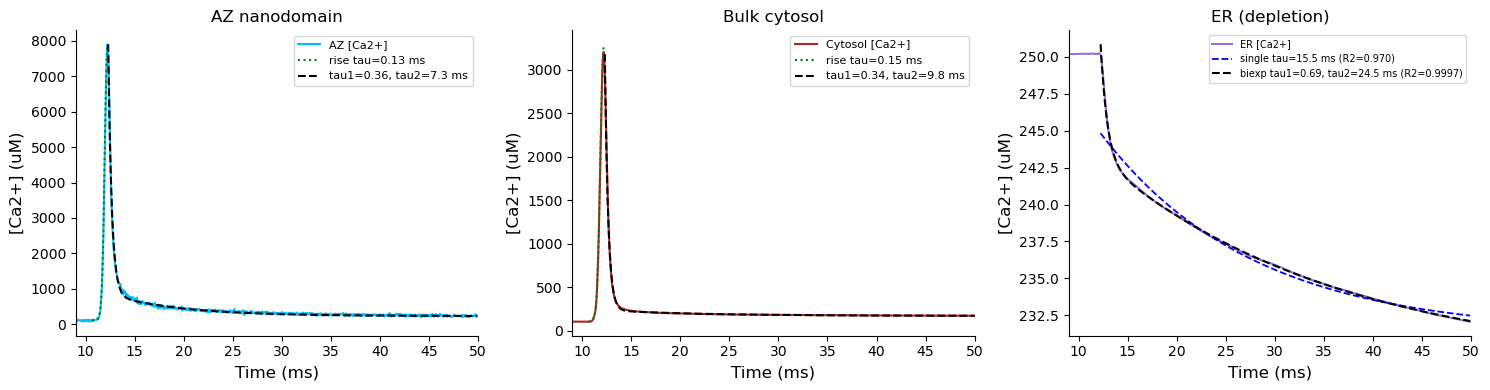

ER depletion fit comparison: single-exp R2=0.9695  bi-exp R2=0.9997


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ---------------- AZ Ca (CaConc, col 1) ----------------
t = load("CaConc", 0); az = load("CaConc", 1)
idx0 = np.searchsorted(t, t_stim)
t_pk, y_pk, idx_pk = time_to_peak(t, az, idx0)
baseline = np.median(az[:idx0]) if idx0 > 0 else az[0]

ttp = (t_pk - t_stim) * 1000
sig_az = fit_sigmoid_rise(t, az, idx0, idx_pk + 1)
dec_1e = decay_time_to_fraction(t, az, idx_pk, baseline) * 1000

fit_az = adaptive_shift_fit(t, az, idx_pk, len(t), 'biexp_decay', p0_taus=[5e-4, 0.008], r2_tol=0.995)

ax = axes[0]
ax.plot(t*1000, az, color='deepskyblue', lw=1.5, label='AZ [Ca2+]')
if sig_az:
    ax.plot((sig_az['fit_t']+t[idx0])*1000, sig_az['fit_y'], 'g:', lw=1.5, label=f"rise tau={sig_az['tau']*1000:.2f} ms")
if fit_az:
    ax.plot((fit_az['tt']+fit_az['t_start'])*1000, fit_az['fit_y'], 'k--', lw=1.5,
            label=f"tau1={fit_az['taus'][0]*1000:.2f}, tau2={fit_az['taus'][1]*1000:.1f} ms")
ax.set_xlim(9, 50); ax.set_xlabel('Time (ms)', fontsize=LABEL_FS)
ax.set_ylabel('[Ca2+] (uM)', fontsize=LABEL_FS); ax.legend(fontsize=LEG_FS-1); ax.set_title('AZ nanodomain', fontsize=LABEL_FS)

results.append(dict(category='Ca2+ pool', signal='AZ (nanodomain)', metric='time to peak', value_ms=ttp))
if sig_az:
    results.append(dict(category='Ca2+ pool', signal='AZ (nanodomain)', metric='rise tau (sigmoid fit)',
                         value_ms=sig_az['tau']*1000, err_ms=sig_az['tau_err']*1000))
results.append(dict(category='Ca2+ pool', signal='AZ (nanodomain)', metric='decay tau (1/e, model-free)', value_ms=dec_1e))
if fit_az:
    results.append(dict(category='Ca2+ pool', signal='AZ (nanodomain)', metric='decay tau (fast, exp fit, adaptive window)',
                         value_ms=fit_az['taus'][0]*1000, err_ms=fit_az['tau_errs'][0]*1000))
    results.append(dict(category='Ca2+ pool', signal='AZ (nanodomain)', metric='decay tau (slow, exp fit, adaptive window)',
                         value_ms=fit_az['taus'][1]*1000, err_ms=fit_az['tau_errs'][1]*1000))

# ---------------- Cytosolic Ca (pre_ca_conc.dat, finer dt) ----------------
t = load("pre_ca_conc.dat", 0); cyto = load("pre_ca_conc.dat", 1)
idx0 = np.searchsorted(t, t_stim)
t_pk, y_pk, idx_pk = time_to_peak(t, cyto, idx0)
baseline = np.median(cyto[:idx0]) if idx0 > 0 else cyto[0]

ttp = (t_pk - t_stim) * 1000
sig_cyto = fit_sigmoid_rise(t, cyto, idx0, idx_pk + 1)
dec_1e = decay_time_to_fraction(t, cyto, idx_pk, baseline) * 1000
fit_cyto = adaptive_shift_fit(t, cyto, idx_pk, len(t), 'biexp_decay', p0_taus=[5e-4, 0.015], r2_tol=0.998)

ax = axes[1]
ax.plot(t*1000, cyto, color='firebrick', lw=1.5, label='Cytosol [Ca2+]')
if sig_cyto:
    ax.plot((sig_cyto['fit_t']+t[idx0])*1000, sig_cyto['fit_y'], 'g:', lw=1.5, label=f"rise tau={sig_cyto['tau']*1000:.2f} ms")
if fit_cyto:
    ax.plot((fit_cyto['tt']+fit_cyto['t_start'])*1000, fit_cyto['fit_y'], 'k--', lw=1.5,
            label=f"tau1={fit_cyto['taus'][0]*1000:.2f}, tau2={fit_cyto['taus'][1]*1000:.1f} ms")
ax.set_xlim(9, 50); ax.set_xlabel('Time (ms)', fontsize=LABEL_FS)
ax.set_ylabel('[Ca2+] (uM)', fontsize=LABEL_FS); ax.legend(fontsize=LEG_FS-1); ax.set_title('Bulk cytosol', fontsize=LABEL_FS)

results.append(dict(category='Ca2+ pool', signal='Cytosol (bulk)', metric='time to peak', value_ms=ttp))
if sig_cyto:
    results.append(dict(category='Ca2+ pool', signal='Cytosol (bulk)', metric='rise tau (sigmoid fit)',
                         value_ms=sig_cyto['tau']*1000, err_ms=sig_cyto['tau_err']*1000))
results.append(dict(category='Ca2+ pool', signal='Cytosol (bulk)', metric='decay tau (1/e, model-free)', value_ms=dec_1e))
if fit_cyto:
    results.append(dict(category='Ca2+ pool', signal='Cytosol (bulk)', metric='decay tau (fast, exp fit, adaptive window)',
                         value_ms=fit_cyto['taus'][0]*1000, err_ms=fit_cyto['tau_errs'][0]*1000))
    results.append(dict(category='Ca2+ pool', signal='Cytosol (bulk)', metric='decay tau (slow, exp fit, adaptive window)',
                         value_ms=fit_cyto['taus'][1]*1000, err_ms=fit_cyto['tau_errs'][1]*1000))

# ---------------- ER Ca depletion (CaConc, col 3) ----------------
t = load("CaConc", 0); er = load("CaConc", 3)
idx0 = np.searchsorted(t, t_stim)
local_max_idx = idx0 + np.argmax(er[idx0:idx0 + 100])
drop = np.where(er[local_max_idx:] <= er[local_max_idx] - 0.1)[0]
idx_onset = local_max_idx + drop[0] if len(drop) else local_max_idx
onset_delay = (t[idx_onset] - t_stim) * 1000

fit_er_1 = fit_exp_deplete_single(t, er, idx_onset, len(t), p0_tau=0.01, weighted=True)
fit_er_2 = fit_biexp_deplete(t, er, idx_onset, len(t), p0_tau1=0.001, p0_tau2=0.03, weighted=True)

ax = axes[2]
ax.plot(t*1000, er, color='mediumpurple', lw=1.5, label='ER [Ca2+]')
if fit_er_1:
    ax.plot((fit_er_1['fit_t']+t[idx_onset])*1000, fit_er_1['fit_y'], 'b--', lw=1.3,
            label=f"single tau={fit_er_1['tau']*1000:.1f} ms (R2={fit_er_1['r2']:.3f})")
if fit_er_2:
    ax.plot((fit_er_2['fit_t']+t[idx_onset])*1000, fit_er_2['fit_y'], 'k--', lw=1.5,
            label=f"biexp tau1={fit_er_2['tau1']*1000:.2f}, tau2={fit_er_2['tau2']*1000:.1f} ms (R2={fit_er_2['r2']:.4f})")
ax.set_xlim(9, 50); ax.set_xlabel('Time (ms)', fontsize=LABEL_FS)
ax.set_ylabel('[Ca2+] (uM)', fontsize=LABEL_FS); ax.legend(fontsize=LEG_FS-2); ax.set_title('ER (depletion)', fontsize=LABEL_FS)

results.append(dict(category='Ca2+ pool', signal='ER (depletion)', metric='onset delay', value_ms=onset_delay))
if fit_er_1:
    results.append(dict(category='Ca2+ pool', signal='ER (depletion)', metric='depletion tau (single exp fit)',
                         value_ms=fit_er_1['tau']*1000, err_ms=fit_er_1['tau_err']*1000))
if fit_er_2:
    results.append(dict(category='Ca2+ pool', signal='ER (depletion)', metric='depletion tau (fast, biexp fit)',
                         value_ms=fit_er_2['tau1']*1000, err_ms=fit_er_2['tau1_err']*1000))
    results.append(dict(category='Ca2+ pool', signal='ER (depletion)', metric='depletion tau (slow, biexp fit)',
                         value_ms=fit_er_2['tau2']*1000, err_ms=fit_er_2['tau2_err']*1000))

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("timescale_ca_pools.png", dpi=DPI, bbox_inches='tight')
plt.show()

r2_single = fit_er_1['r2']
r2_biexp = fit_er_2['r2']
print(f"ER depletion fit comparison: single-exp R2={r2_single:.4f}  bi-exp R2={r2_biexp:.4f}")


## 4. Buffering & extrusion kinetics (calbindin, SERCA, PMCA)


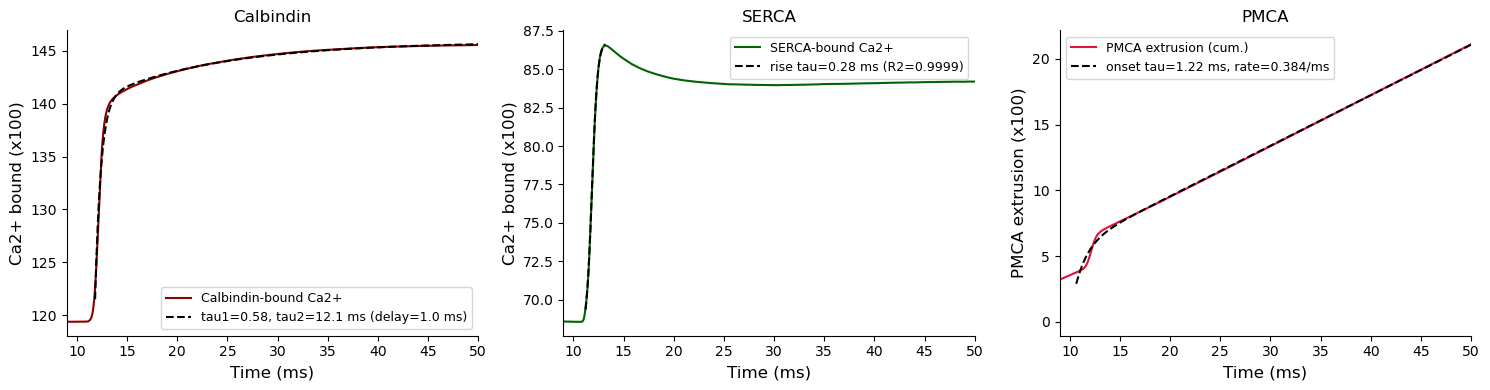

PMCA combined fit R2 = 0.9993


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ---------------- Calbindin ----------------

t = load("calB.dat", 0)
bound = load("calB.dat", (2, 3, 4, 5, 6, 7, 8, 9))
calb = np.sum(bound, axis=1) / 100.0
idx0 = np.searchsorted(t, t_stim)
idx_onset = detect_onset(t, calb, idx0, len(t) - 1, frac=0.05, rising=True)
onset_delay_calb = (t[idx_onset] - t_stim) * 1000
fit_calb = adaptive_shift_fit(t, calb, idx_onset, len(t), 'biexp_rise', p0_taus=[6e-4, 0.012], r2_tol=0.995)

ax = axes[0]
ax.plot(t*1000, calb, color='darkred', lw=1.5, label='Calbindin-bound Ca2+')
if fit_calb:
    ax.plot((fit_calb['tt']+fit_calb['t_start'])*1000, fit_calb['fit_y'], 'k--', lw=1.5,
            label=f"tau1={fit_calb['taus'][0]*1000:.2f}, tau2={fit_calb['taus'][1]*1000:.1f} ms (delay={onset_delay_calb:.1f} ms)")
ax.set_xlim(9, 50); ax.set_xlabel('Time (ms)', fontsize=LABEL_FS)
ax.set_ylabel('Ca2+ bound (x100)', fontsize=LABEL_FS); ax.legend(fontsize=LEG_FS); ax.set_title('Calbindin', fontsize=LABEL_FS)

results.append(dict(category='Buffer/extrusion', signal='Calbindin', metric='onset delay', value_ms=onset_delay_calb))
if fit_calb:
    results.append(dict(category='Buffer/extrusion', signal='Calbindin', metric='binding rise tau (fast, biexp fit, from onset)',
                         value_ms=fit_calb['taus'][0]*1000, err_ms=fit_calb['tau_errs'][0]*1000))
    results.append(dict(category='Buffer/extrusion', signal='Calbindin', metric='binding rise tau (slow, biexp fit, from onset)',
                         value_ms=fit_calb['taus'][1]*1000, err_ms=fit_calb['tau_errs'][1]*1000))

# ---------------- SERCA ----------------

t = load("sercaMol.dat", 0)
x1 = load("sercaMol.dat", 2); x2 = load("sercaMol.dat", 3)
y2 = load("sercaMol.dat", 4); y1 = load("sercaMol.dat", 5)
serca = (x1 + x2*2 + y2*2 + y1) / 100.0
idx0 = np.searchsorted(t, t_stim)
idx_pk = np.argmax(serca)
idx_onset = detect_onset(t, serca, idx0, idx_pk, frac=0.05, rising=True)
onset_delay_serca = (t[idx_onset] - t_stim) * 1000
fit_serca = fit_sigmoid_rise(t, serca, idx_onset, idx_pk + 1)

ax = axes[1]
ax.plot(t*1000, serca, color='darkgreen', lw=1.5, label='SERCA-bound Ca2+')
if fit_serca:
    ax.plot((fit_serca['fit_t']+t[idx_onset])*1000, fit_serca['fit_y'], 'k--', lw=1.5,
            label=f"rise tau={fit_serca['tau']*1000:.2f} ms (R2={fit_serca['r2']:.4f})")
ax.set_xlim(9, 50); ax.set_xlabel('Time (ms)', fontsize=LABEL_FS)
ax.set_ylabel('Ca2+ bound (x100)', fontsize=LABEL_FS); ax.legend(fontsize=LEG_FS); ax.set_title('SERCA', fontsize=LABEL_FS)

results.append(dict(category='Buffer/extrusion', signal='SERCA', metric='time to peak', value_ms=(t[idx_pk]-t_stim)*1000))
results.append(dict(category='Buffer/extrusion', signal='SERCA', metric='onset delay', value_ms=onset_delay_serca))
if fit_serca:
    results.append(dict(category='Buffer/extrusion', signal='SERCA', metric='binding rise tau (sigmoid fit, from onset to peak)',
                         value_ms=fit_serca['tau']*1000, err_ms=fit_serca['tau_err']*1000))

# ---------------- PMCA ----------------
def _pmca_model(t, A, tau, rate, C):
    return A * (1 - np.exp(-t / tau)) + rate * t + C

t = load("pmca_leak.dat", 0)
flux = load("pmca_leak.dat", 1); leak = load("pmca_leak.dat", 2)
net = (flux + leak) / 100
idx0 = np.searchsorted(t, t_stim)
tt = t[idx0:] - t[idx0]
yy = net[idx0:]
p0 = [yy.max()*0.3, 0.001, (yy[-1]-yy[0])/tt[-1]*0.7, yy[0]]
popt, pcov = curve_fit(_pmca_model, tt, yy, p0=p0, maxfev=40000)
perr = np.sqrt(np.diag(pcov))
onset_tau_pmca, onset_err_pmca, steady_rate = popt[1]*1000, perr[1]*1000, popt[2]/1000
resid = yy - _pmca_model(tt, *popt)
r2_pmca = 1 - np.sum(resid**2)/np.sum((yy-yy.mean())**2)

ax = axes[2]
ax.plot(t*1000, net, color='crimson', lw=1.5, label='PMCA extrusion (cum.)')
ax.plot(t[idx0:]*1000, _pmca_model(tt, *popt), 'k--', lw=1.5,
        label=f"onset tau={onset_tau_pmca:.2f} ms, rate={steady_rate:.3f}/ms")
ax.set_xlim(9, 50); ax.set_xlabel('Time (ms)', fontsize=LABEL_FS)
ax.set_ylabel('PMCA extrusion (x100)', fontsize=LABEL_FS); ax.legend(fontsize=LEG_FS); ax.set_title('PMCA', fontsize=LABEL_FS)

results.append(dict(category='Buffer/extrusion', signal='PMCA', metric='onset tau (combined onset+linear fit)',
                     value_ms=onset_tau_pmca, err_ms=onset_err_pmca))
results.append(dict(category='Buffer/extrusion', signal='PMCA', metric='steady-state rate (units/ms)', value_ms=steady_rate, err_ms=np.nan))

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("timescale_buffers.png", dpi=DPI, bbox_inches='tight')
plt.show()

print(f"PMCA combined fit R2 = {r2_pmca:.4f}")


## 5. Vesicle release kinetics (synchronous vs. asynchronous)

`syncRel`/`asyncRel` list individual release-event times. Binning these
into a cumulative histogram and doing nonlinear least squares on
`1-exp(-t/tau)` is workable but not the statistically correct tool for a
set of `n` individual event times: binning throws away information, and
least squares on a CDF implicitly (and wrongly) treats each bin as an
independent, equal-variance Gaussian observation.

The right tool is **maximum likelihood** directly on the event times. We
compare four nested models per population, all evaluated by exact
likelihood (never a binned approximation):

- `uniform(0,T)` -- constant rate from the AP (0 parameters)
- `uniform(d,T)` -- constant rate starting after a delay `d` (1 parameter;
  the MLE of a uniform distribution's left edge is simply `min(data)`)
- `trunc-exp(tau)` -- decaying rate from the AP (1 parameter)
- `delayed trunc-exp(d,tau)` -- decaying rate starting after a delay
  (2 parameters)

All four are truncated to the actual observation window `T` (0.05 s
recording, 39.4 ms after t_stim), which correctly accounts for only
seeing events up to the end of the simulation. Comparing all four by AIC
matters because a plain (non-delayed) exponential and a plain uniform can
*both* fit poorly for the same reason (neither can represent a genuine
onset delay), which is exactly what made the v2 async CDF fit visibly
miss the data's slow start.


Synchronous (n=126):
  delayed trunc-exp(d,tau)     k=2  AIC= -1053.87  d=1.70ms tau=5.58ms  <-- best (lowest AIC)
  trunc-exp(tau)               k=1  AIC=  -989.16  tau=7.44ms
  uniform(d,T)                 k=1  AIC=  -824.37  d=1.70ms
  uniform(0,T)                 k=0  AIC=  -815.22  

Asynchronous (n=36):
  uniform(d,T)                 k=1  AIC=  -236.58  d=2.98ms  <-- best (lowest AIC)
  delayed trunc-exp(d,tau)     k=2  AIC=  -234.58  d=2.98ms tau=1124078789.31ms
  uniform(0,T)                 k=0  AIC=  -232.92  
  trunc-exp(tau)               k=1  AIC=  -230.67  tau=1000.00ms


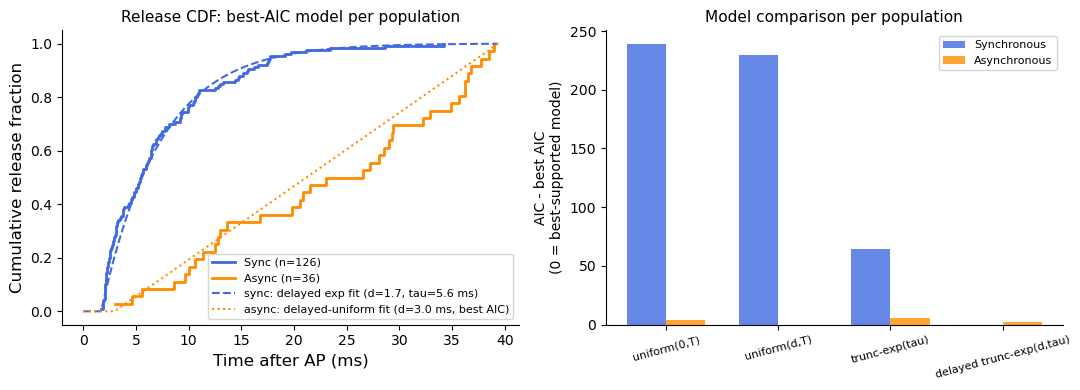

In [7]:
sync = load("syncRel")[:, 0]
asyn = load("asyncRel")[:, 0]

t_rec_end = load("ryrMol.dat", 0)[-1]           # simulation duration
T_window = t_rec_end - t_stim                    # observation window relative to the AP

def release_times(events, t_stim):
    ev = np.sort(events - t_stim)
    return ev[ev >= 0]

ts_sync = release_times(sync, t_stim)
ts_async = release_times(asyn, t_stim)


release_stats = {}
for name, data in [("Synchronous", ts_sync), ("Asynchronous", ts_async)]:
    n = len(data)
    ll_unif = loglik_uniform(data, T_window)
    d_hat, ll_unif_delay = fit_delayed_uniform_mle(data, T_window)
    tau_mle, ll_exp = fit_truncated_exp_mle(data, T_window)
    d_exp, tau_delayed, ll_delayed_exp = fit_delayed_trunc_exp_mle(data, T_window)

    models = {
        'uniform(0,T)':          dict(k=0, ll=ll_unif),
        'uniform(d,T)':          dict(k=1, ll=ll_unif_delay, d=d_hat),
        'trunc-exp(tau)':        dict(k=1, ll=ll_exp, tau=tau_mle),
        'delayed trunc-exp(d,tau)': dict(k=2, ll=ll_delayed_exp, d=d_exp, tau=tau_delayed),
    }
    for m in models.values():
        m['aic'] = 2 * m['k'] - 2 * m['ll']
    best_name = min(models, key=lambda k: models[k]['aic'])

    lat_mean = np.mean(data) * 1000
    lat_t50 = np.median(data) * 1000
    release_stats[name] = dict(n=n, models=models, best=best_name, lat_mean=lat_mean, lat_t50=lat_t50,
                                d_hat=d_hat, tau_mle=tau_mle, d_exp=d_exp, tau_delayed=tau_delayed)

    print(f"\n{name} (n={n}):")
    for mname, m in sorted(models.items(), key=lambda kv: kv[1]['aic']):
        extra = ' '.join(f"{k}={v*1000:.2f}ms" for k, v in m.items() if k in ('d', 'tau'))
        star = '  <-- best (lowest AIC)' if mname == best_name else ''
        print(f"  {mname:28s} k={m['k']}  AIC={m['aic']:9.2f}  {extra}{star}")

# --- results table entries ---
results.append(dict(category='Vesicle release', signal='Synchronous', metric='mean latency', value_ms=release_stats['Synchronous']['lat_mean']))
results.append(dict(category='Vesicle release', signal='Synchronous', metric='t50 (median latency)', value_ms=release_stats['Synchronous']['lat_t50']))
results.append(dict(category='Vesicle release', signal='Synchronous', metric='onset delay (delayed trunc-exp MLE)',
                     value_ms=release_stats['Synchronous']['d_exp']*1000))
results.append(dict(category='Vesicle release', signal='Synchronous', metric='release tau (delayed trunc-exp MLE)',
                     value_ms=release_stats['Synchronous']['tau_delayed']*1000))
results.append(dict(category='Vesicle release', signal='Asynchronous', metric='mean latency', value_ms=release_stats['Asynchronous']['lat_mean']))
results.append(dict(category='Vesicle release', signal='Asynchronous', metric='t50 (median latency)', value_ms=release_stats['Asynchronous']['lat_t50']))
results.append(dict(category='Vesicle release', signal='Asynchronous', metric='onset delay (delayed-uniform MLE)',
                     value_ms=release_stats['Asynchronous']['d_hat']*1000))
# async: best-supported model is uniform-after-delay -- adding a decay term
# (delayed trunc-exp) does not improve AIC (its tau runs to the fit's
# upper bound, i.e. "no decay"), so we do not report a release tau for it.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
def cdf(data):
    n = np.arange(1, len(data)+1)
    return data, n/len(data)
ax.step(*[a*1000 if i==0 else a for i,a in enumerate(cdf(ts_sync))], where='post', color='royalblue', lw=2, label=f'Sync (n={len(ts_sync)})')
ax.step(*[a*1000 if i==0 else a for i,a in enumerate(cdf(ts_async))], where='post', color='darkorange', lw=2, label=f'Async (n={len(ts_async)})')

tt = np.linspace(0, T_window*1000, 400)

d_s, tau_s = release_stats['Synchronous']['d_exp'], release_stats['Synchronous']['tau_delayed']
sync_cdf = np.where(tt < d_s*1000, 0.0,
                     (1 - np.exp(-(tt/1000 - d_s)/tau_s)) / (1 - np.exp(-(T_window - d_s)/tau_s)))
ax.plot(tt, sync_cdf, 'royalblue', ls='--', lw=1.5,
        label=f'sync: delayed exp fit (d={d_s*1000:.1f}, tau={tau_s*1000:.1f} ms)')

d_a = release_stats['Asynchronous']['d_hat']
async_cdf = np.where(tt < d_a*1000, 0.0, (tt/1000 - d_a) / (T_window - d_a))
ax.plot(tt, async_cdf, 'darkorange', ls=':', lw=1.5,
        label=f'async: delayed-uniform fit (d={d_a*1000:.1f} ms, best AIC)')

ax.set_xlabel('Time after AP (ms)', fontsize=LABEL_FS); ax.set_ylabel('Cumulative release fraction', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS-1); ax.set_title('Release CDF: best-AIC model per population', fontsize=LABEL_FS-1)

ax = axes[1]
model_order = ['uniform(0,T)', 'uniform(d,T)', 'trunc-exp(tau)', 'delayed trunc-exp(d,tau)']
x = np.arange(len(model_order))
width = 0.35
for offset, (name, color) in zip([-width/2, width/2], [('Synchronous', 'royalblue'), ('Asynchronous', 'darkorange')]):
    aics = [release_stats[name]['models'][m]['aic'] for m in model_order]
    best_aic = min(aics)
    d_aics = [a - best_aic for a in aics]  # 0 = best model for that population
    ax.bar(x + offset, d_aics, width, color=color, alpha=0.8, label=name)
ax.set_xticks(x); ax.set_xticklabels(model_order, fontsize=TICK_FS-2, rotation=15)
ax.set_ylabel('AIC - best AIC\n(0 = best-supported model)', fontsize=LABEL_FS-2)
ax.set_title('Model comparison per population', fontsize=LABEL_FS-1)
ax.legend(fontsize=LEG_FS-1)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("timescale_release.png", dpi=DPI, bbox_inches='tight')
plt.show()


**Result.** Adding a delay term improves *both* populations, but in
different ways -- and that difference is itself informative:

- **Synchronous**: `delayed trunc-exp(d,tau)` is the best-supported model
  by a wide margin (AIC beats plain `trunc-exp` by ~65, and beats
  `uniform(0,T)` by far more). The fitted delay (~1.7 ms) matches the AZ
  Ca2+ rise time to peak almost exactly -- release genuinely cannot start
  until local Ca2+ has risen -- and once that delay is accounted for
  separately, the decay itself is *faster and tighter* than the v2
  estimate (tau ~5.6 ms vs. the earlier 7.4 ms, which was blurred by
  forcing one exponential to also explain the delay).
- **Asynchronous**: `uniform(d,T)` (constant rate starting after a delay,
  1 parameter) is the best-supported model, beating plain `uniform(0,T)`
  (no delay) and beating both exponential variants. Adding a decay term on
  top of the delay (`delayed trunc-exp`) does *not* improve AIC further --
  its tau still runs to the fit's upper bound, i.e. "no decay" remains the
  best description of the rate once the ~3 ms onset delay is accounted
  for.

So **both** release components have a real onset delay (release can't
start instantaneously), but only synchronous release shows a genuine
decaying rate afterward -- asynchronous release, once it starts, proceeds
at a roughly constant rate for as long as this ~39 ms window lets us see.
That still doesn't mean asynchronous release has no characteristic decay
in the underlying biology; it means this single-AP, single-run, 36-event
dataset can't resolve one, and reporting a specific decay number for it
would imply more precision than the data support. The honest summary
statistic remains the **mean/median latency** (~23 ms), carried into the
cascade summary below. Pooling async event times across replicate
runs/seeds would increase `n` and could resolve a real tau if one exists.

## 6. Summary: the cascade of timescales


In [8]:
df = pd.DataFrame(results)
df['value_ms'] = df['value_ms'].astype(float)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 120)
print(df.to_string(index=False))
df.to_csv("figS1_model_fits_timescales_summary.csv", index=False)


        category          signal                                             metric  value_ms   err_ms
    Channel flux            VDCC                                       time to peak  1.310000      NaN
    Channel flux            VDCC                     rise time (10-90%, model-free)  0.607588      NaN
    Channel flux            VDCC                 rise tau (sigmoid fit, true onset)  0.144485 0.007884
    Channel flux            VDCC          decay tau (1/e, model-free, clean window)  0.373793      NaN
    Channel flux            VDCC               decay tau (exp fit, adaptive window)  0.097077 0.003531
    Channel flux             RyR                                       time to peak  1.810000      NaN
    Channel flux             RyR                     rise time (10-90%, model-free)  0.503418      NaN
    Channel flux             RyR                 rise tau (sigmoid fit, true onset)  0.112663 0.004464
    Channel flux             RyR                        decay tau (1/e, m

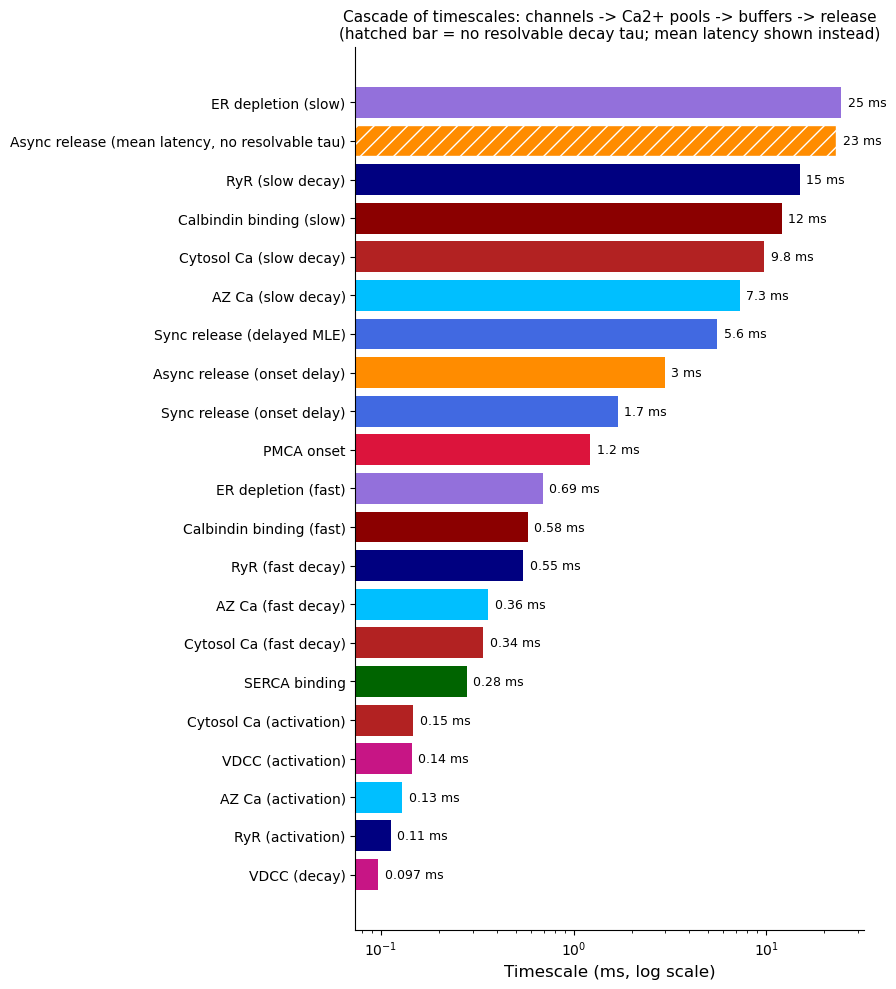

In [9]:
def get_val(signal, metric):
    row = df[(df['signal'] == signal) & (df['metric'] == metric)]
    return float(row['value_ms'].iloc[0]) if len(row) else np.nan

# One representative timescale per signal for the headline cascade plot.
# Decay/depletion/release: prefer the best-supported parametric fit.
# Rise phases: sigmoid tau for driven (channel/pool) rises, exp-fit tau for
# true relaxation rises (buffers), model-free metric only where no
# parametric fit is statistically meaningful (async release rate).
headline = {
    "VDCC (activation)":     get_val("VDCC", "rise tau (sigmoid fit, true onset)"),
    "VDCC (decay)":          get_val("VDCC", "decay tau (exp fit, adaptive window)"),
    "RyR (activation)":      get_val("RyR", "rise tau (sigmoid fit, true onset)"),
    "RyR (fast decay)":      get_val("RyR", "decay tau (fast, exp fit, adaptive window)"),
    "RyR (slow decay)":      get_val("RyR", "decay tau (slow, exp fit, adaptive window)"),
    "AZ Ca (activation)":    get_val("AZ (nanodomain)", "rise tau (sigmoid fit)"),
    "AZ Ca (fast decay)":    get_val("AZ (nanodomain)", "decay tau (fast, exp fit, adaptive window)"),
    "AZ Ca (slow decay)":    get_val("AZ (nanodomain)", "decay tau (slow, exp fit, adaptive window)"),
    "Cytosol Ca (activation)": get_val("Cytosol (bulk)", "rise tau (sigmoid fit)"),
    "Cytosol Ca (fast decay)": get_val("Cytosol (bulk)", "decay tau (fast, exp fit, adaptive window)"),
    "Cytosol Ca (slow decay)": get_val("Cytosol (bulk)", "decay tau (slow, exp fit, adaptive window)"),
    "ER depletion (fast)":   get_val("ER (depletion)", "depletion tau (fast, biexp fit)"),
    "ER depletion (slow)":   get_val("ER (depletion)", "depletion tau (slow, biexp fit)"),
    "Calbindin binding (fast)": get_val("Calbindin", "binding rise tau (fast, biexp fit, from onset)"),
    "Calbindin binding (slow)": get_val("Calbindin", "binding rise tau (slow, biexp fit, from onset)"),
    "SERCA binding":         get_val("SERCA", "binding rise tau (sigmoid fit, from onset to peak)"),
    "PMCA onset":            get_val("PMCA", "onset tau (combined onset+linear fit)"),
    "Sync release (onset delay)":    get_val("Synchronous", "onset delay (delayed trunc-exp MLE)"),
    "Sync release (delayed MLE)":    get_val("Synchronous", "release tau (delayed trunc-exp MLE)"),
    "Async release (onset delay)":   get_val("Asynchronous", "onset delay (delayed-uniform MLE)"),
    "Async release (mean latency, no resolvable tau)": get_val("Asynchronous", "mean latency"),
}

group_color = {
    "VDCC (activation)": "mediumvioletred", "VDCC (decay)": "mediumvioletred",
    "RyR (activation)": "navy", "RyR (fast decay)": "navy", "RyR (slow decay)": "navy",
    "AZ Ca (activation)": "deepskyblue", "AZ Ca (fast decay)": "deepskyblue", "AZ Ca (slow decay)": "deepskyblue",
    "Cytosol Ca (activation)": "firebrick", "Cytosol Ca (fast decay)": "firebrick", "Cytosol Ca (slow decay)": "firebrick",
    "ER depletion (fast)": "mediumpurple", "ER depletion (slow)": "mediumpurple",
    "Calbindin binding (fast)": "darkred", "Calbindin binding (slow)": "darkred",
    "SERCA binding": "darkgreen", "PMCA onset": "crimson",
    "Sync release (onset delay)": "royalblue", "Sync release (delayed MLE)": "royalblue",
    "Async release (onset delay)": "darkorange", "Async release (mean latency, no resolvable tau)": "darkorange",
}

items = [(k, v) for k, v in headline.items() if not np.isnan(v)]
items.sort(key=lambda kv: kv[1])
labels = [k for k, v in items]
vals = [v for k, v in items]
colors = [group_color[k] for k in labels]
hatches = ['//' if 'no resolvable' in k else None for k in labels]

fig, ax = plt.subplots(figsize=(9, 10))
y = np.arange(len(labels))
bars = ax.barh(y, vals, color=colors)
for b, h in zip(bars, hatches):
    if h:
        b.set_hatch(h); b.set_edgecolor('white')
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=TICK_FS)
ax.set_xscale('log')
ax.set_xlabel('Timescale (ms, log scale)', fontsize=LABEL_FS)
ax.set_title('Cascade of timescales: channels -> Ca2+ pools -> buffers -> release\n(hatched bar = no resolvable decay tau; mean latency shown instead)', fontsize=LABEL_FS-1)
for yi, v in zip(y, vals):
    ax.text(v * 1.08, yi, f"{v:.2g} ms", va='center', fontsize=TICK_FS-1)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("Neurotransmission_singleAP_timescale_summary.png", dpi=DPI, bbox_inches='tight', transparent=True)
plt.show()


## 11. Supplementary figure


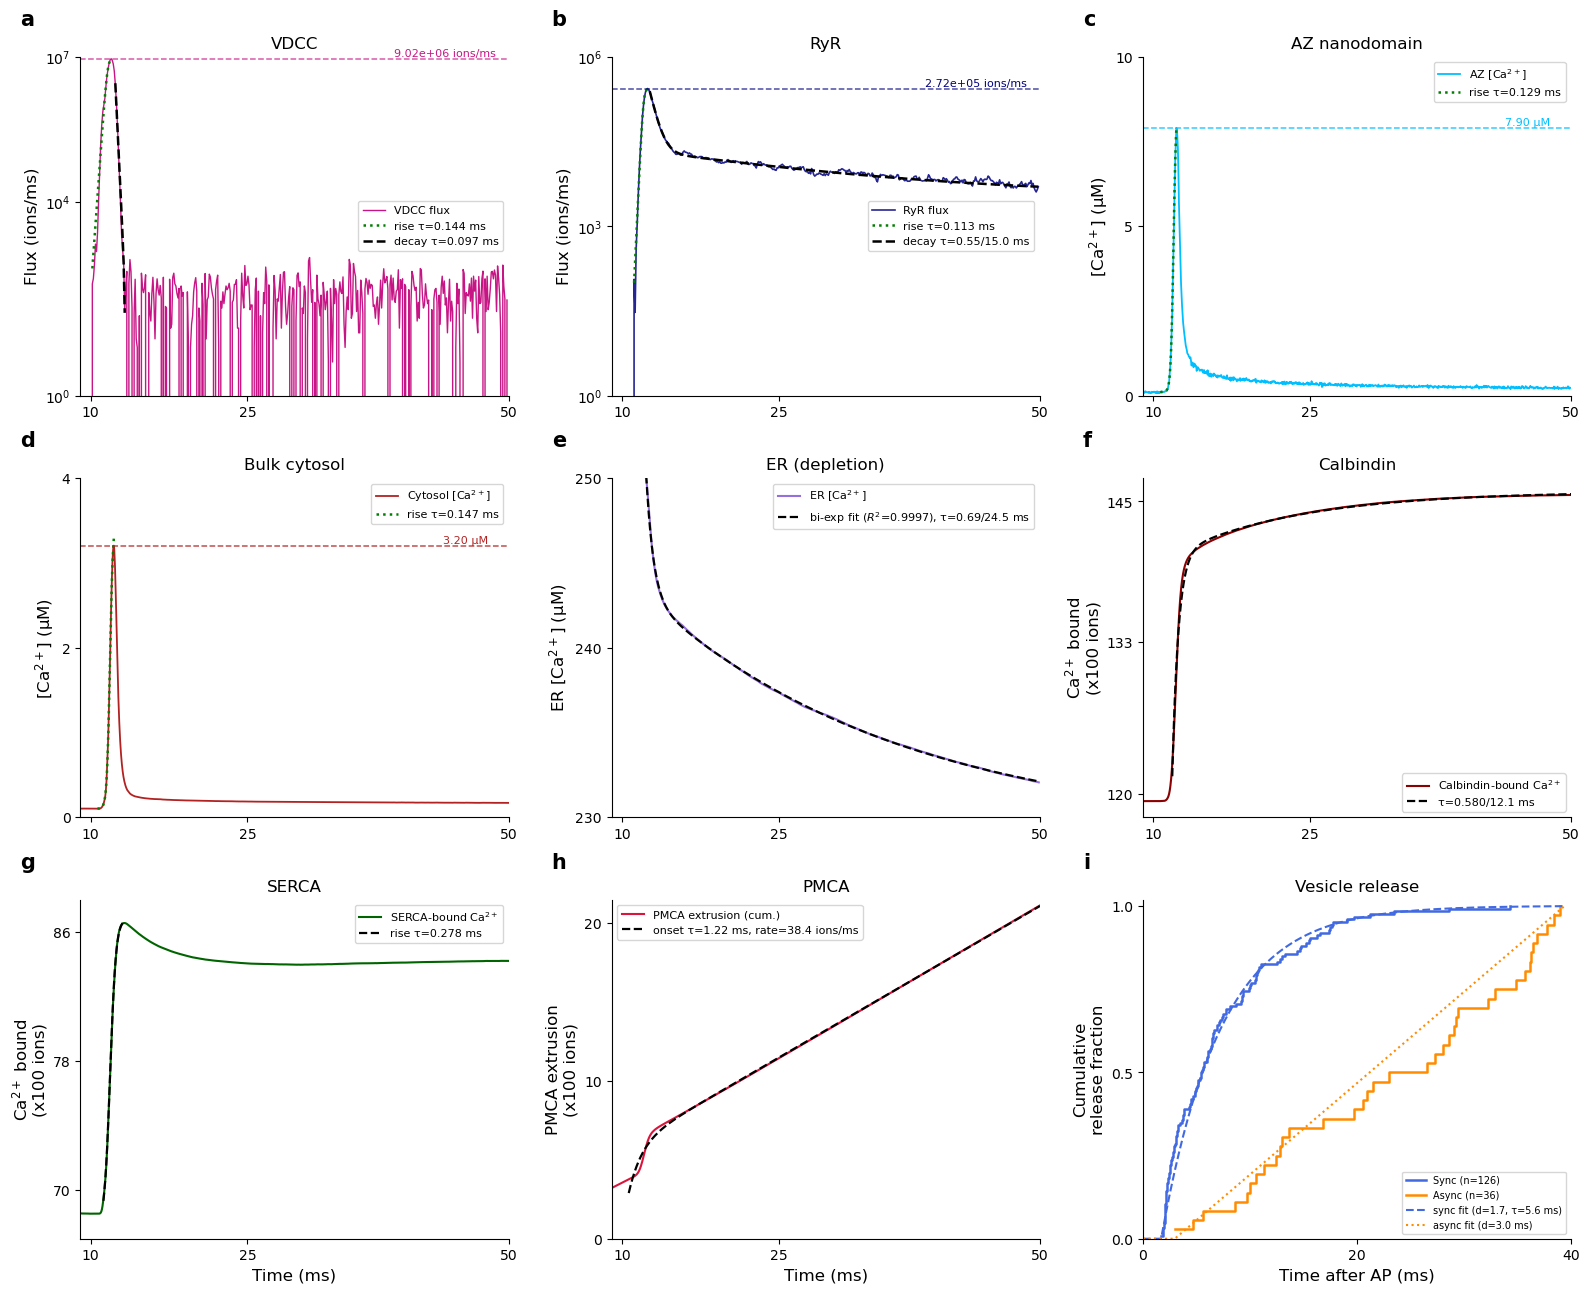

In [10]:
from matplotlib.ticker import NullLocator

X_TICKS = [10, 25, 50]  # shared by every panel except (i); matches _v2.ipynb exactly

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()


def _label_panel(ax, letter):
    ax.text(-0.14, 1.08, letter, transform=ax.transAxes, fontsize=15, fontweight='bold', va='bottom')


# ---------------- (a) VDCC -- reuses fit_vdcc/sig_vdcc from Section 4 ----------------
ax = axes[0]
t = load("vdccCaFluxRate.dat", 0)
f = load("vdccCaFluxRate.dat", 1)
vdcc_peak = f.max()

ax.plot(t * 1000, f, color='mediumvioletred', lw=1.0, label='VDCC flux')
if sig_vdcc:
    ax.plot((sig_vdcc['fit_t'] + t[idx_onset_vdcc]) * 1000, sig_vdcc['fit_y'], 'g:', lw=1.8,
            label=f"rise τ={sig_vdcc['tau']*1000:.3f} ms")
if fit_vdcc:
    ax.plot((fit_vdcc['tt'] + fit_vdcc['t_start']) * 1000, fit_vdcc['fit_y'], 'k--', lw=1.8,
            label=f"decay τ={fit_vdcc['taus'][0]*1000:.3f} ms")
ax.axhline(vdcc_peak, color='mediumvioletred', ls='--', lw=1.1, alpha=0.7)
ax.text(0.97, vdcc_peak, f'{vdcc_peak:.2e} ions/ms', color='mediumvioletred', fontsize=TICK_FS - 2,
        ha='right', va='bottom', transform=ax.get_yaxis_transform())
ax.set_yscale('log')
ax.set_xlim(9, 50)
ax.set_xticks(X_TICKS)
ax.set_ylim(1, 1e7)  # explicit top so the 1e7 tick (above the 9.02e6 peak) is visible
ax.set_yticks([1, 1e4, 1e7])
ax.yaxis.set_minor_locator(NullLocator())
ax.set_ylabel('Flux (ions/ms)', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS - 1, loc='center right')
ax.set_title('VDCC', fontsize=LABEL_FS)
_label_panel(ax, 'a')

# ---------------- (b) RyR -- reuses fit_ryr/sig_ryr from Section 4 ----------------
ax = axes[1]
t = load("ryrCaFluxRate.dat", 0)
f = load("ryrCaFluxRate.dat", 1)
ryr_peak = f.max()

ax.plot(t * 1000, f, color='navy', lw=1.2, alpha=0.85, label='RyR flux')
if sig_ryr:
    ax.plot((sig_ryr['fit_t'] + t[idx_onset_ryr]) * 1000, sig_ryr['fit_y'], 'g:', lw=1.8,
            label=f"rise τ={sig_ryr['tau']*1000:.3f} ms")
if fit_ryr:
    ax.plot((fit_ryr['tt'] + fit_ryr['t_start']) * 1000, fit_ryr['fit_y'], 'k--', lw=1.8,
            label=f"decay τ={fit_ryr['taus'][0]*1000:.2f}/{fit_ryr['taus'][1]*1000:.1f} ms")
ax.axhline(ryr_peak, color='navy', ls='--', lw=1.1, alpha=0.7)
ax.text(0.97, ryr_peak, f'{ryr_peak:.2e} ions/ms', color='navy', fontsize=TICK_FS - 2,
        ha='right', va='bottom', transform=ax.get_yaxis_transform())
ax.set_yscale('log')
ax.set_xlim(9, 50)
ax.set_xticks(X_TICKS)
ax.set_ylim(1, 1e6)  # explicit top so the 1e6 tick (above the 2.72e5 peak) is visible
ax.set_yticks([1, 1e3, 1e6])
ax.yaxis.set_minor_locator(NullLocator())
ax.set_ylabel('Flux (ions/ms)', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS - 1, loc='center right')
ax.set_title('RyR', fontsize=LABEL_FS)
_label_panel(ax, 'b')

# ---------------- (c) AZ Ca -- rise fit recomputed fresh (unit fix, cheap) ----------------
ax = axes[2]
t = load("CaConc", 0)
az = load("CaConc", 1) / 1000.0  # nM -> uM (verified: raw max 7899.4 -> 7.90 uM, cited in text)
idx0_az = np.searchsorted(t, t_stim)
t_pk, y_pk, idx_pk_az = time_to_peak(t, az, idx0_az)
sig_az_supp = fit_sigmoid_rise(t, az, idx0_az, idx_pk_az + 1)
az_peak = az.max()

ax.plot(t * 1000, az, color='deepskyblue', lw=1.3, label='AZ [Ca$^{2+}$]')
if sig_az_supp:
    ax.plot((sig_az_supp['fit_t'] + t[idx0_az]) * 1000, sig_az_supp['fit_y'], 'g:', lw=1.8,
            label=f"rise τ={sig_az_supp['tau']*1000:.3f} ms")
ax.axhline(az_peak, color='deepskyblue', ls='--', lw=1.1, alpha=0.8)
ax.text(48, az_peak, f'{az_peak:.2f} µM', color='deepskyblue', fontsize=TICK_FS - 2, ha='right', va='bottom')
ax.set_xlim(9, 50)
ax.set_xticks(X_TICKS)
ax.set_ylim(0, 10)  # matches the main figure's shared AZ/Cytosol y-scale (panel c: [0, 5, 10])
ax.set_yticks([0, 5, 10])
ax.set_ylabel('[Ca$^{2+}$] (µM)', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS - 1)
ax.set_title('AZ nanodomain', fontsize=LABEL_FS)
_label_panel(ax, 'c')

# ---------------- (d) Cytosol Ca -- rise fit recomputed fresh (same reason) ----------------
ax = axes[3]
t = load("pre_ca_conc.dat", 0)
cyto = load("pre_ca_conc.dat", 1) / 1000.0  # same nM -> uM conversion (raw max 3202.9 -> 3.20 uM)
idx0_cyto = np.searchsorted(t, t_stim)
t_pk, y_pk, idx_pk_cyto = time_to_peak(t, cyto, idx0_cyto)
sig_cyto_supp = fit_sigmoid_rise(t, cyto, idx0_cyto, idx_pk_cyto + 1)
cyto_peak = cyto.max()

ax.plot(t * 1000, cyto, color='firebrick', lw=1.3, label='Cytosol [Ca$^{2+}$]')
if sig_cyto_supp:
    ax.plot((sig_cyto_supp['fit_t'] + t[idx0_cyto]) * 1000, sig_cyto_supp['fit_y'], 'g:', lw=1.8,
            label=f"rise τ={sig_cyto_supp['tau']*1000:.3f} ms")
ax.axhline(cyto_peak, color='firebrick', ls='--', lw=1.1, alpha=0.8)
ax.text(48, cyto_peak, f'{cyto_peak:.2f} µM', color='firebrick', fontsize=TICK_FS - 2, ha='right', va='bottom')
ax.set_xlim(9, 50)
ax.set_xticks(X_TICKS)
ax.set_ylim(0, 4)  # same shared scale as panel (c), matching the main figure's combined panel c
ax.set_yticks([0, 2, 4])
ax.set_ylabel('[Ca$^{2+}$] (µM)', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS - 1)
ax.set_title('Bulk cytosol', fontsize=LABEL_FS)
_label_panel(ax, 'd')

# ---------------- (e) ER -- reuses fit_er_2 from Section 5 ----------------

ax = axes[4]
t = load("CaConc", 0)
er = load("CaConc", 3)
idx0_er = np.searchsorted(t, t_stim)
local_max_idx_er = idx0_er + np.argmax(er[idx0_er:idx0_er + 100])
drop_er = np.where(er[local_max_idx_er:] <= er[local_max_idx_er] - 0.1)[0]
idx_onset_er = local_max_idx_er + drop_er[0] if len(drop_er) else local_max_idx_er

ax.plot(t * 1000, er, color='mediumpurple', lw=1.5, label='ER [Ca$^{2+}$]')
ax.plot((fit_er_2['fit_t'] + t[idx_onset_er]) * 1000, fit_er_2['fit_y'], 'k--', lw=1.6,
        label=f"bi-exp fit ($R^2$={fit_er_2['r2']:.4f}), τ={fit_er_2['tau1']*1000:.2f}/{fit_er_2['tau2']*1000:.1f} ms")
ax.set_xlim(9, 50)
ax.set_xticks(X_TICKS)
ax.set_ylim(230, 250)  # matches the main figure's ER panel exactly (232.1-250.2 uM range)
ax.set_yticks([230, 240, 250])
ax.set_ylabel('ER [Ca$^{2+}$] (µM)', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS - 1)
ax.set_title('ER (depletion)', fontsize=LABEL_FS)
_label_panel(ax, 'e')

# ---------------- (f) Calbindin -- reuses fit_calb from Section 6 ----------------
ax = axes[5]
t = load("calB.dat", 0)
bound = load("calB.dat", (2, 3, 4, 5, 6, 7, 8, 9))
calb = np.sum(bound, axis=1) / 100.0

ax.plot(t * 1000, calb, color='darkred', lw=1.5, label='Calbindin-bound Ca$^{2+}$')
if fit_calb:
    ax.plot((fit_calb['tt'] + fit_calb['t_start']) * 1000, fit_calb['fit_y'], 'k--', lw=1.6,
            label=f"τ={fit_calb['taus'][0]*1000:.3f}/{fit_calb['taus'][1]*1000:.1f} ms")
ax.set_xlim(9, 50)
ax.set_xticks(X_TICKS)

ax.set_ylim(118, 147)
ax.set_yticks([120, 133, 145])
ax.set_ylabel('Ca$^{2+}$ bound\n(x100 ions)', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS - 1)
ax.set_title('Calbindin', fontsize=LABEL_FS)
_label_panel(ax, 'f')

# ---------------- (g) SERCA -- reuses fit_serca from Section 6 ----------------
ax = axes[6]
t = load("sercaMol.dat", 0)
x1 = load("sercaMol.dat", 2)
x2 = load("sercaMol.dat", 3)
y2 = load("sercaMol.dat", 4)
y1 = load("sercaMol.dat", 5)
serca = (x1 + x2 * 2 + y2 * 2 + y1) / 100.0

idx0_serca = np.searchsorted(t, t_stim)
idx_pk_serca = np.argmax(serca)
idx_onset_serca = detect_onset(t, serca, idx0_serca, idx_pk_serca, frac=0.05, rising=True)

ax.plot(t * 1000, serca, color='darkgreen', lw=1.5, label='SERCA-bound Ca$^{2+}$')
if fit_serca:
    ax.plot((fit_serca['fit_t'] + t[idx_onset_serca]) * 1000, fit_serca['fit_y'], 'k--', lw=1.6,
            label=f"rise τ={fit_serca['tau']*1000:.3f} ms")
ax.set_xlim(9, 50)
ax.set_xticks(X_TICKS)
ax.set_ylim(67, 88)  # SERCA's own raw-bound range (68.54-86.55)
ax.set_yticks([70, 78, 86])
ax.set_xlabel('Time (ms)', fontsize=LABEL_FS)
ax.set_ylabel('Ca$^{2+}$ bound\n(x100 ions)', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS - 1)
ax.set_title('SERCA', fontsize=LABEL_FS)
_label_panel(ax, 'g')

# ---------------- (h) PMCA -- reuses popt from Section 6 ----------------
ax = axes[7]
t = load("pmca_leak.dat", 0)
flux = load("pmca_leak.dat", 1)
leak = load("pmca_leak.dat", 2)
net = (flux + leak) / 100
idx0_pmca = np.searchsorted(t, t_stim)

ax.plot(t * 1000, net, color='crimson', lw=1.5, label='PMCA extrusion (cum.)')
ax.plot(t[idx0_pmca:] * 1000, _pmca_model(t[idx0_pmca:] - t[idx0_pmca], *popt), 'k--', lw=1.6,
        label=f"onset τ={popt[1]*1000:.2f} ms, rate={popt[2]/1000*100:.1f} ions/ms")
ax.set_xlim(9, 50)
ax.set_xticks(X_TICKS)
ax.set_ylim(0, 21.5)  # matches the main figure's PMCA panel ticks ([0, 10, 20]) directly
ax.set_yticks([0, 10, 20])
ax.set_xlabel('Time (ms)', fontsize=LABEL_FS)
ax.set_ylabel('PMCA extrusion\n(x100 ions)', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS - 1)
ax.set_title('PMCA', fontsize=LABEL_FS)
_label_panel(ax, 'h')

# ---------------- (i) Vesicle release -- reuses release_stats from Section 7 ----------------
ax = axes[8]


def _cdf(data):
    n = np.arange(1, len(data) + 1)
    return data, n / len(data)


ax.step(*[a * 1000 if i == 0 else a for i, a in enumerate(_cdf(ts_sync))], where='post',
        color='royalblue', lw=1.8, label=f'Sync (n={len(ts_sync)})')
ax.step(*[a * 1000 if i == 0 else a for i, a in enumerate(_cdf(ts_async))], where='post',
        color='darkorange', lw=1.8, label=f'Async (n={len(ts_async)})')

d_exp_s = release_stats["Synchronous"]["d_exp"]
tau_delayed_s = release_stats["Synchronous"]["tau_delayed"]
d_hat_a = release_stats["Asynchronous"]["d_hat"]

tt_r = np.linspace(0, T_window * 1000, 400)
sync_cdf = np.where(tt_r < d_exp_s * 1000, 0.0,
                     (1 - np.exp(-(tt_r / 1000 - d_exp_s) / tau_delayed_s))
                     / (1 - np.exp(-(T_window - d_exp_s) / tau_delayed_s)))
ax.plot(tt_r, sync_cdf, 'royalblue', ls='--', lw=1.5,
        label=f'sync fit (d={d_exp_s*1000:.1f}, τ={tau_delayed_s*1000:.1f} ms)')
async_cdf = np.where(tt_r < d_hat_a * 1000, 0.0, (tt_r / 1000 - d_hat_a) / (T_window - d_hat_a))
ax.plot(tt_r, async_cdf, 'darkorange', ls=':', lw=1.5, label=f'async fit (d={d_hat_a*1000:.1f} ms)')

ax.set_xlim(0, 40)
ax.set_xticks([0, 20, 40])
ax.set_ylim(0, 1.02)
ax.set_yticks([0, 0.5, 1])
ax.set_xlabel('Time after AP (ms)', fontsize=LABEL_FS)
ax.set_ylabel('Cumulative\nrelease fraction', fontsize=LABEL_FS)
ax.legend(fontsize=LEG_FS - 2, loc='lower right')
ax.set_title('Vesicle release', fontsize=LABEL_FS)
_label_panel(ax, 'i')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=TICK_FS)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("figS1_model_fits_timescales.png", dpi=DPI, bbox_inches='tight')
plt.show()


## 12. Supplementary table


In [11]:
def _sci(x, sig=3):
    
    if x == 0:
        return "0"
    ax = abs(x)
    if ax >= 1e4 or ax < 1e-2:
        exp = int(f"{x:.{sig-1}e}".split('e')[1])
        mant = x / (10 ** exp)
        return f"{mant:.{sig-1}f}\\times10^{{{exp}}}"
    exponent = int(np.floor(np.log10(ax)))
    decimals = max(0, sig - 1 - exponent)
    return f"{x:.{decimals}f}"


vdcc_decay_popt = fit_vdcc['popt']            # (A, tau, C)
ryr_decay_popt = fit_ryr['popt']              # (A1, tau1, A2, tau2, C)
calb_popt = fit_calb['popt']                  # (A1, tau1, A2, tau2, C)

rows = [
    dict(component="VDCC flux (rise)",
         fn=r"Sigmoid: $C + A/(1+e^{-(t-t_{1/2})/\tau})$",
         params=rf"$A={_sci(sig_vdcc['A'])}$, $C\approx {_sci(sig_vdcc['C'])}$ (ions/ms)",
         rise=f"{sig_vdcc['tau']*1000:.3f}", decay="--"),
    dict(component="VDCC flux (decay)",
         fn=r"Single exponential: $A\,e^{-t/\tau} + C$",
         params=rf"$A={_sci(vdcc_decay_popt[0])}$, $C={_sci(vdcc_decay_popt[2])}$ (ions/ms)",
         rise="--", decay=f"{fit_vdcc['taus'][0]*1000:.3f}"),
    dict(component="RyR flux (rise)",
         fn=r"Sigmoid: $C + A/(1+e^{-(t-t_{1/2})/\tau})$",
         params=rf"$A={_sci(sig_ryr['A'])}$, $C\approx {_sci(sig_ryr['C'])}$ (ions/ms)",
         rise=f"{sig_ryr['tau']*1000:.3f}", decay="--"),
    dict(component="RyR flux (decay)",
         fn=r"Bi-exponential: $A_1 e^{-t/\tau_1} + A_2 e^{-t/\tau_2} + C$",
         params=rf"$A_1={_sci(ryr_decay_popt[0])}$, $A_2={_sci(ryr_decay_popt[2])}$, "
                rf"$C={_sci(ryr_decay_popt[4])}$ (ions/ms)",
         rise="--", decay=f"{fit_ryr['taus'][0]*1000:.3f} / {fit_ryr['taus'][1]*1000:.2f}"),
    dict(component="AZ Ca\\textsuperscript{2+} (rise)",
         fn=r"Sigmoid: $C + A/(1+e^{-(t-t_{1/2})/\tau})$",
         params=rf"$A={_sci(sig_az_supp['A'])}$, $C={_sci(sig_az_supp['C'])}$ ($\mu$M)",
         rise=f"{sig_az_supp['tau']*1000:.3f}", decay="--"),
    dict(component="Cytosol Ca\\textsuperscript{2+} (rise)",
         fn=r"Sigmoid: $C + A/(1+e^{-(t-t_{1/2})/\tau})$",
         params=rf"$A={_sci(sig_cyto_supp['A'])}$, $C={_sci(sig_cyto_supp['C'])}$ ($\mu$M)",
         rise=f"{sig_cyto_supp['tau']*1000:.3f}", decay="--"),
    dict(component="ER Ca\\textsuperscript{2+} (depletion)",
         fn=r"Bi-exponential depletion: $C - A_1(1-e^{-t/\tau_1}) - A_2(1-e^{-t/\tau_2})$",
         params=rf"$A_1={_sci(fit_er_2['A1'])}$, $A_2={_sci(fit_er_2['A2'])}$, "
                rf"$C={_sci(fit_er_2['C'])}$ ($\mu$M)",
         rise="--", decay=f"{fit_er_2['tau1']*1000:.3f} / {fit_er_2['tau2']*1000:.2f}"),
    dict(component="Calbindin (rise)",
         fn=r"Bi-exponential rise: $C + A_1(1-e^{-t/\tau_1}) + A_2(1-e^{-t/\tau_2})$",
         params=rf"$A_1={_sci(calb_popt[0])}$, $A_2={_sci(calb_popt[2])}$, "
                rf"$C={_sci(calb_popt[4])}$ ($\times100$ ions)",
         rise=f"{fit_calb['taus'][0]*1000:.3f} / {fit_calb['taus'][1]*1000:.2f}", decay="--"),
    dict(component="SERCA (rise)",
         fn=r"Sigmoid: $C + A/(1+e^{-(t-t_{1/2})/\tau})$",
         params=rf"$A={_sci(fit_serca['A'])}$, $C={_sci(fit_serca['C'])}$ ($\times100$ ions)",
         rise=f"{fit_serca['tau']*1000:.3f}", decay="--"),
    dict(component="PMCA (extrusion)",
         fn=r"Onset + linear: $A(1-e^{-t/\tau}) + \mathrm{rate}\cdot t + C$",
         params=rf"$A={_sci(popt[0])}$, rate$={_sci(popt[2]/1000*100)}$ ions/ms, "
                rf"$C={_sci(popt[3])}$ ($\times100$ ions)",
         rise=f"{popt[1]*1000:.3f} (onset)", decay="--"),
    dict(component="Synchronous release",
         fn="Delayed truncated-exponential (MLE)",
         params=rf"delay $d={release_stats['Synchronous']['d_exp']*1000:.2f}$ ms",
         rise="--", decay=f"{release_stats['Synchronous']['tau_delayed']*1000:.2f}"),
    dict(component="Asynchronous release",
         fn="Delayed uniform (MLE)",
         params=rf"delay $d={release_stats['Asynchronous']['d_hat']*1000:.2f}$ ms",
         rise="--", decay="no resolvable decay"),
]

_header = r"""\begin{table}[htbp]
\centering
\caption{Fitting functions and parameters underlying the timescales cited in the Results section. Rise/decay $\tau$ in ms; ``/'' separates fast/slow components of a bi-exponential fit. Amplitude/baseline parameters ($A$, $C$) are in each signal's native units (ions/ms for flux, $\mu$M for Ca\textsuperscript{2+} concentration, $\times100$ ions for buffered/extruded counts), matching the main figure.}
\label{tab:timescale_fits}
\small
\begin{tabular}{p{2.6cm} p{4.2cm} p{4.6cm} p{1.6cm} p{2.0cm}}
\hline
\textbf{Component} & \textbf{Fitting function} & \textbf{Fitted parameters} & \textbf{Rise $\tau$ (ms)} & \textbf{Decay $\tau$ (ms)} \\
\hline
"""
_body = "\n".join(f"{r['component']} & {r['fn']} & {r['params']} & {r['rise']} & {r['decay']} \\\\" for r in rows)
_footer = r"""
\hline
\end{tabular}
\end{table}"""

latex_timescale_table = _header + _body + _footer
print(latex_timescale_table)

with open("figS1_model_fits_timescales_supplementary_table.tex", "w") as _f:
    _f.write(latex_timescale_table)


\begin{table}[htbp]
\centering
\caption{Fitting functions and parameters underlying the timescales cited in the Results section. Rise/decay $\tau$ in ms; ``/'' separates fast/slow components of a bi-exponential fit. Amplitude/baseline parameters ($A$, $C$) are in each signal's native units (ions/ms for flux, $\mu$M for Ca\textsuperscript{2+} concentration, $\times100$ ions for buffered/extruded counts), matching the main figure.}
\label{tab:timescale_fits}
\small
\begin{tabular}{p{2.6cm} p{4.2cm} p{4.6cm} p{1.6cm} p{2.0cm}}
\hline
\textbf{Component} & \textbf{Fitting function} & \textbf{Fitted parameters} & \textbf{Rise $\tau$ (ms)} & \textbf{Decay $\tau$ (ms)} \\
\hline
VDCC flux (rise) & Sigmoid: $C + A/(1+e^{-(t-t_{1/2})/\tau})$ & $A=9.77\times10^{6}$, $C\approx 1.33\times10^{-8}$ (ions/ms) & 0.144 & -- \\
VDCC flux (decay) & Single exponential: $A\,e^{-t/\tau} + C$ & $A=2.82\times10^{6}$, $C=-214$ (ions/ms) & -- & 0.097 \\
RyR flux (rise) & Sigmoid: $C + A/(1+e^{-(t-t_{1/2})/\tau})